## 1. 라이브러리 불러오기 및 폰트설치
- 사용된 환경은 주피터에서 진행되었습니다.
- 참고된 코드들은 퍼실님께서 올려주신 마스터코드와 노드를 참고하여서 만들었습니다.

In [5]:
!wget -O NanumBarunGothic.ttf https://raw.githubusercontent.com/hiun/NanumBarunGothic/master/NanumBarunGothic.ttf

--2026-05-14 05:23:54--  https://raw.githubusercontent.com/hiun/NanumBarunGothic/master/NanumBarunGothic.ttf
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.108.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4186060 (4.0M) [application/octet-stream]
Saving to: ‘NanumBarunGothic.ttf’

NanumBarunGothic.tt 100%[===================>]   3.99M  17.1MB/s    in 0.2s    

2026-05-14 05:23:55 (17.1 MB/s) - ‘NanumBarunGothic.ttf’ saved [4186060/4186060]



In [6]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

font_path = "./NanumBarunGothic.ttf"

fm.fontManager.addfont(font_path)
font_name = fm.FontProperties(fname=font_path).get_name()

plt.rc("font", family=font_name)
plt.rcParams["axes.unicode_minus"] = False

print("적용된 폰트:", font_name)

적용된 폰트: NanumBarunGothic


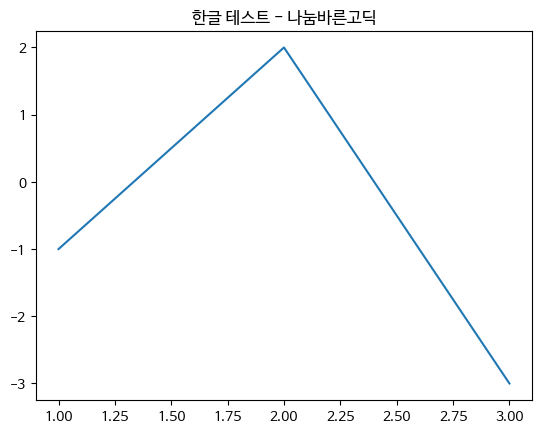

In [7]:
plt.title("한글 테스트 - 나눔바른고딕")
plt.plot([1, 2, 3], [-1, 2, -3])
plt.show()

In [4]:
import matplotlib as mpl              # 한글 폰트를 설정하고 그래프를 더 선명하게 출력
import matplotlib.pyplot as plt       # 그래프를 그릴 때 사용하는 기능
import matplotlib.font_manager as fm  # 글꼴을 관리하는 기능

%config InlineBackend.figure_format = 'retina' # 그래프를 retina로 출력 그래프를 흐릿하지않게 하기위함

fontpath = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf' #폰트의 파일 경로
font = fm.FontProperties(fname=fontpath, size=9) # 사용된 폰트의 사이즈는 9
plt.rc('font', family='NanumBarunGothic') # 사용된 폰트의 스타일은 나눔바른고딕 폰트
mpl.font_manager.findfont(font) # 이폰트가 경로에 존재하는지 확인해주는 코드

print("슝=3") 

슝=3


In [11]:
import numpy as np                   # NumPy 라이브러리 불러오기 (배열, 행렬, 수치 계산용)
import torch                         # PyTorch 전체 라이브러리 불러오기
import torch.nn as nn                # 신경망 레이어 관련 모듈 불러오기
import torch.nn.functional as F      # 활성화 함수 등 함수형 API 불러오기
import torch.optim as optim          # Optimizer(Adam, SGD 등) 불러오기
import matplotlib.pyplot as plt      # 그래프 시각화 라이브러리 불러오기

import re                            # 정규표현식 처리 라이브러리
import os                            # 운영체제(OS) 및 파일 경로 제어 라이브러리
import io                            # 입출력(Input/Output) 처리 라이브러리
import time                          # 시간 측정 및 대기 기능 라이브러리
import random                        # 랜덤 숫자 생성 라이브러리
import math                          # 수학 함수 라이브러리

import seaborn                       # 고급 시각화 라이브러리 (Attention Heatmap 등에 사용)

print(torch.__version__)             # 현재 설치된 PyTorch 버전 출력

2.7.1+cu118


## 2. Positional Encoding
- Transformer는 Self-Attention 만 사용하기 때문에 단어의 순서를 알 수 없기때문에
 그래서 단어 위치 정보를 임베딩 벡터에 추가해야 하는데, 그 역할을 하는 것이 Positional Encoding입니다.

In [12]:
def positional_encoding(pos, d_model):   # Positional Encoding 함수 정의
                                          # pos : 문장의 최대 길이(위치 개수)
                                          # d_model : 임베딩 벡터 차원 수

    def cal_angle(position, i):           # 특정 위치(position)와 차원(i)에 대한 각도 계산 함수
        return position / np.power(10000, int(i) / d_model)
                                          # Transformer 논문에서 사용한 공식
                                          # 위치마다 서로 다른 주파수를 만들기 위한 계산

    def get_posi_angle_vec(position):     # 하나의 위치(position)에 대한 전체 벡터 생성
        return [cal_angle(position, i) for i in range(d_model)]
                                          # d_model 차원 수만큼 angle 값 생성

    sinusoid_table = np.array([get_posi_angle_vec(pos_i) for pos_i in range(pos)])
                                          # 모든 위치(pos)에 대해 positional encoding 값 생성
                                          # 결과 shape : (pos, d_model)

    sinusoid_table[:, 0::2] = np.sin(sinusoid_table[:, 0::2])
                                          # 짝수 인덱스(0,2,4...)에는 sin 함수 적용

    sinusoid_table[:, 1::2] = np.cos(sinusoid_table[:, 1::2])
                                          # 홀수 인덱스(1,3,5...)에는 cos 함수 적용

    return sinusoid_table                 # 최종 Positional Encoding 테이블 반환

print("슝=3")                             # 코드 실행 확인용 문자열 출력

슝=3


## 3. Multi-Head Attention
- Attention을 여러 개로 나누어서
서로 다른 관점으로 문장을 동시에 보는 방법

- 각각의 head를 문법, 의미, 거리 관계
  등을 각각 학습해서 더 풍부하게 문맥을 이해하는 방식

In [13]:
class MultiHeadAttention(nn.Module):                         # Multi-Head Attention 클래스를 정의, PyTorch의 nn.Module 상속
    def __init__(self, d_model, num_heads):                   # 초기 설정 함수, d_model과 head 개수를 입력받음
        super(MultiHeadAttention, self).__init__()            # 부모 클래스(nn.Module)의 초기화 함수 실행
        self.num_heads = num_heads                            # Attention head 개수 저장
        self.d_model = d_model                                # 입력/출력 벡터 차원 저장

        self.depth = d_model // self.num_heads                # head 하나가 담당할 차원 수 계산

        self.W_q = nn.Linear(d_model, d_model)                # Query(Q)를 만들기 위한 선형 변환 Layer
        self.W_k = nn.Linear(d_model, d_model)                # Key(K)를 만들기 위한 선형 변환 Layer
        self.W_v = nn.Linear(d_model, d_model)                # Value(V)를 만들기 위한 선형 변환 Layer

        self.linear = nn.Linear(d_model, d_model)             # 여러 head 결과를 합친 뒤 최종 출력으로 바꾸는 Linear Layer

    def scaled_dot_product_attention(self, Q, K, V, mask):    # Scaled Dot-Product Attention 계산 함수
        d_k = K.size(-1)                                      # Key 벡터의 마지막 차원 크기 가져오기
        QK = torch.matmul(Q, K.transpose(-2, -1))             # Q와 K를 곱해서 단어 간 유사도 점수 계산

        scaled_qk = QK / torch.sqrt(torch.tensor(d_k, dtype=torch.float32))  
                                                               # 유사도 점수를 sqrt(d_k)로 나누어 값이 너무 커지는 것 방지

        if mask is not None:                                  # mask가 있을 경우
            scaled_qk += (mask * -1e9)                        # 가려야 할 위치에 매우 작은 값을 더해 softmax 결과가 0에 가깝게 만듦

        attentions = F.softmax(scaled_qk, dim=-1)             # softmax로 attention 비율 계산
        out = torch.matmul(attentions, V)                     # attention 비율만큼 V 값을 가중합하여 출력 생성

        return out, attentions                                # attention 결과와 attention 가중치 반환

    def split_heads(self, x):                                 # 하나의 큰 벡터를 여러 head로 나누는 함수
        batch_size = x.size(0)                                # batch 크기 가져오기
        x = x.view(batch_size, -1, self.num_heads, self.depth)# (batch, seq_len, d_model)을 (batch, seq_len, head수, head차원)으로 변경
        x = x.permute(0, 2, 1, 3)                             # (batch, head수, seq_len, head차원) 순서로 변경

        return x                                              # head로 나눈 결과 반환

    def combine_heads(self, x):                               # 나눠진 여러 head를 다시 하나로 합치는 함수
        batch_size = x.size(0)                                # batch 크기 가져오기
        x = x.permute(0, 2, 1, 3)                             # (batch, seq_len, head수, head차원) 순서로 변경
        x = x.contiguous().view(batch_size, -1, self.d_model) # 여러 head를 합쳐서 다시 (batch, seq_len, d_model) 형태로 변경

        return x                                              # 합쳐진 결과 반환

    def forward(self, Q, K, V, mask=None):                    # 실제 Multi-Head Attention이 실행되는 함수
        WQ = self.W_q(Q)                                      # 입력 Q를 Linear Layer에 통과시켜 Query 생성
        WK = self.W_k(K)                                      # 입력 K를 Linear Layer에 통과시켜 Key 생성
        WV = self.W_v(V)                                      # 입력 V를 Linear Layer에 통과시켜 Value 생성

        WQ_splits = self.split_heads(WQ)                      # Query를 여러 head로 나눔
        WK_splits = self.split_heads(WK)                      # Key를 여러 head로 나눔
        WV_splits = self.split_heads(WV)                      # Value를 여러 head로 나눔

        out, attention_weights = self.scaled_dot_product_attention(
            WQ_splits, WK_splits, WV_splits, mask)            # 각 head별 Attention 계산

        out = self.combine_heads(out)                         # 여러 head의 결과를 다시 하나로 합침
        out = self.linear(out)                                # 최종 Linear Layer를 통과시켜 출력 생성

        return out, attention_weights                         # 최종 출력과 attention 가중치 반환

print("슝=3")                                                 

슝=3


## 4. Position-wise Feed-Forward Network
- Encoder/Decoder Layer 안에 들어가는 작은 신경망
- Attention이 문장 속 단어들 간의 관계를 파악했다면,
FFN은 각 단어 벡터를 한 번 더 깊게 변환해서 표현력을 높이는 역할을 합니다.

In [14]:
class PoswiseFeedForwardNet(nn.Module):                 # Position-wise Feed Forward Network 클래스 정의
    def __init__(self, d_model, d_ff):                  # d_model: 입력/출력 차원, d_ff: 내부 은닉층 차원
        super(PoswiseFeedForwardNet, self).__init__()   # 부모 클래스(nn.Module) 초기화

        self.w_1 = nn.Linear(d_model, d_ff)             # 첫 번째 Linear Layer
                                                         # 입력 차원(d_model)을 더 큰 차원(d_ff)으로 확장

        self.w_2 = nn.Linear(d_ff, d_model)             # 두 번째 Linear Layer
                                                         # 다시 원래 차원(d_model)으로 축소

        self.relu = nn.ReLU()                           # ReLU 활성화 함수 정의

    def forward(self, x):                               # 실제 연산이 수행되는 함수
        out = self.relu(self.w_1(x))                    # 첫 번째 Linear 수행 후 ReLU 활성화 함수 적용
        out = self.w_2(out)                             # 두 번째 Linear 수행

        return out                                      # 최종 결과 반환

print("슝=3")                                          

슝=3


## ENCORDER 구현

In [15]:
class EncoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout):
        super(EncoderLayer, self).__init__()

        self.enc_self_attn = MultiHeadAttention(d_model, n_heads)
        self.ffn = PoswiseFeedForwardNet(d_model, d_ff)

        self.norm_1 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_2 = nn.LayerNorm(d_model, eps=1e-6)

        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask):
        """
        Multi-Head Attention
        """
        residual = x
        out = self.norm_1(x)
        out, enc_attn = self.enc_self_attn(out, out, out, mask)
        out = self.dropout(out)
        out += residual

        """
        Position-Wise Feed Forward Network
        """
        residual = out
        out = self.norm_2(out)
        out = self.ffn(out)
        out = self.dropout(out)
        out += residual

        return out, enc_attn

print("슝=3")

슝=3


## DECORDER 구현

In [16]:
class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout):
        super(DecoderLayer, self).__init__()

        self.dec_self_attn = MultiHeadAttention(d_model, num_heads)
        self.enc_dec_attn = MultiHeadAttention(d_model, num_heads)

        self.ffn = PoswiseFeedForwardNet(d_model, d_ff)

        self.norm_1 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_2 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_3 = nn.LayerNorm(d_model, eps=1e-6)

        self.dropout = nn.Dropout(dropout)

    def forward(self, x, enc_out, causality_mask, padding_mask):
        """
        Masked Multi-Head Attention
        """
        residual = x
        out = self.norm_1(x)
        out, dec_attn = self.dec_self_attn(out, out, out, padding_mask)
        out = self.dropout(out)
        out += residual

        """
        Multi-Head Attention
        """
        residual = out
        out = self.norm_2(out)
        out, dec_enc_attn = self.enc_dec_attn(out, enc_out, enc_out, causality_mask)
        out = self.dropout(out)
        out += residual

        """
        Position-Wise Feed Forward Network
        """
        residual = out
        out = self.norm_3(out)
        out = self.ffn(out)
        out = self.dropout(out)
        out += residual

        return out, dec_attn, dec_enc_attn

print("슝=3")

슝=3


## Encoder 와 decoder를 정의하고 Transformer로 조립

In [17]:
class Encoder(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout):
        super(Encoder, self).__init__()
        self.n_layers = n_layers
        self.enc_layers = nn.ModuleList([
            EncoderLayer(d_model, n_heads, d_ff, dropout)
            for _ in range(n_layers)
        ])

    def forward(self, x, mask):
        out = x
        enc_attns = []

        for i in range(self.n_layers):
            out, enc_attn = self.enc_layers[i](out, mask)
            enc_attns.append(enc_attn)

        return out, enc_attns

print("슝=3")

슝=3


In [18]:
class Decoder(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout):
        super(Decoder, self).__init__()
        self.n_layers = n_layers
        self.dec_layers = nn.ModuleList([
            DecoderLayer(d_model, n_heads, d_ff, dropout)
            for _ in range(n_layers)
        ])

    def forward(self, x, enc_out, causality_mask, padding_mask):
        out = x

        dec_attns = []
        dec_enc_attns = []
        for i in range(self.n_layers):
            out, dec_attn, dec_enc_attn = \
                self.dec_layers[i](out, enc_out, causality_mask, padding_mask)

            dec_attns.append(dec_attn)
            dec_enc_attns.append(dec_enc_attn)

        return out, dec_attns, dec_enc_attns

print("슝=3")

슝=3


## 정의된 encoder 와 decoder로 transformer를 완성합니다

In [19]:
class Transformer(nn.Module):
    def __init__(self,
                 n_layers,
                 d_model,
                 n_heads,
                 d_ff,
                 src_vocab_size,
                 tgt_vocab_size,
                 pos_len,
                 dropout=0.2,
                 shared=True):
        super(Transformer, self).__init__()
        self.d_model = float(d_model)

        self.enc_emb = nn.Embedding(src_vocab_size, d_model)
        self.dec_emb = nn.Embedding(tgt_vocab_size, d_model)

        self.pos_encoding = self.positional_encoding(pos_len, d_model)
        self.dropout = nn.Dropout(dropout)

        self.encoder = Encoder(n_layers, d_model, n_heads, d_ff, dropout)
        self.decoder = Decoder(n_layers, d_model, n_heads, d_ff, dropout)

        self.fc = nn.Linear(d_model, tgt_vocab_size)

        self.shared = shared
        if shared:
            self.fc.weight = self.dec_emb.weight

    def positional_encoding(self, pos_len, d_model):
        position = torch.arange(0, pos_len).unsqueeze(1).float()
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * -(torch.log(torch.tensor(10000.0)) / d_model))
        pos_encoding = torch.zeros(pos_len, d_model)
        pos_encoding[:, 0::2] = torch.sin(position * div_term)
        pos_encoding[:, 1::2] = torch.cos(position * div_term)
        return pos_encoding

    def embedding(self, emb, x):
        seq_len = x.size(1)
        out = emb(x)

        if self.shared:
            out *= torch.sqrt(torch.tensor(self.d_model))

        out += self.pos_encoding[:seq_len, :].unsqueeze(0)
        out = self.dropout(out)

        return out

    def forward(self, enc_in, dec_in, enc_mask, causality_mask, dec_mask):
        enc_in = self.embedding(self.enc_emb, enc_in)
        dec_in = self.embedding(self.dec_emb, dec_in)

        enc_out, enc_attns = self.encoder(enc_in, enc_mask)

        dec_out, dec_attns, dec_enc_attns = \
            self.decoder(dec_in, enc_out, causality_mask, dec_mask)

        logits = self.fc(dec_out)

        return logits, enc_attns, dec_attns, dec_enc_attns

print("슝=3")

슝=3


## Masking + Masking 시각화
- 쓰는 이유 실제 생성 상황에서는 미래 단어를 알수가 없으므로 가려서 추론때 성능이 이상해지는걸 방지

In [20]:
import torch
import numpy as np

def generate_padding_mask(seq):
    mask = (seq == 0).float()
    return mask.unsqueeze(1).unsqueeze(2)

def generate_causality_mask(size):
    """Causal Mask 생성 (Upper triangular matrix)"""
    mask = torch.triu(torch.ones(size, size), diagonal=1)
    return mask

def generate_masks(src, tgt):
    enc_mask = generate_padding_mask(src)
    dec_enc_mask = generate_padding_mask(tgt)
    seq_len = tgt.shape[-1]
    causal_mask = generate_causality_mask(seq_len)
    batch_size = src.shape[0]
    dec_mask = causal_mask.expand(batch_size, 1, seq_len, seq_len)

    return enc_mask, dec_enc_mask, dec_mask

print("슝=3")

슝=3


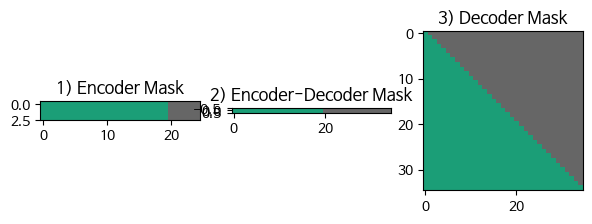

In [21]:
import matplotlib.pyplot as plt

batch, length = 16, 20
src_padding = 5
tgt_padding = 15

src_pad = torch.zeros((batch, src_padding))
tgt_pad = torch.zeros((batch, tgt_padding))

sample_data = torch.ones((batch, length))
sample_src = torch.cat([sample_data, src_pad], dim=-1)
sample_tgt = torch.cat([sample_data, tgt_pad], dim=-1)

enc_mask, dec_enc_mask, dec_mask = generate_masks(sample_src, sample_tgt)

fig = plt.figure(figsize=(7, 7))

ax1 = fig.add_subplot(131)
ax2 = fig.add_subplot(132)
ax3 = fig.add_subplot(133)

ax1.set_title('1) Encoder Mask')
ax2.set_title('2) Encoder-Decoder Mask')
ax3.set_title('3) Decoder Mask')

ax1.imshow(enc_mask[:3, 0, 0].numpy(), cmap='Dark2')
ax2.imshow(dec_enc_mask[0, 0].numpy(), cmap='Dark2')
ax3.imshow(dec_mask[0, 0].numpy(), cmap='Dark2')

plt.show()

## LearningRateSchedule 클래스를 상속받아 구현

In [22]:
class LearningRateScheduler:
    def __init__(self, d_model, warmup_steps=4000):
        self.d_model = d_model
        self.warmup_steps = warmup_steps

    def __call__(self, step):
        step = torch.tensor(step, dtype=torch.float32)
        arg1 = step ** -0.5
        arg2 = step * (self.warmup_steps ** -1.5)
        return (self.d_model ** -0.5) * torch.minimum(arg1, arg2)

model = nn.Linear(10, 10)
optimizer = optim.Adam(
    model.parameters(),
    lr=1e-9,
    betas=(0.9, 0.98),
    eps=1e-9)

print("슝=3")

슝=3


## GPU 설정 및 환경 확인 및 라이브러리 불러오기

In [28]:
!pip install sentencepiece

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 11.4 MB/s eta 0:00:00a 0:00:01


In [29]:
import os, re, math, random, time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
import sentencepiece as spm

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("torch:", torch.__version__, "| device:", device)


torch: 2.7.1+cu118 | device: cuda


## 데이터 다운로드

In [30]:
HOME = os.getenv("HOME")
candidate_dirs = [
    os.path.join(HOME, "work/transformer/data"),
    "/content",
    ".",
]

DATA_DIR = None
for d in candidate_dirs:
    if os.path.exists(os.path.join(d, "korean-english-park.train.ko")):
        DATA_DIR = d
        break

if DATA_DIR is None:
    DATA_DIR = candidate_dirs[0]
    os.makedirs(DATA_DIR, exist_ok=True)
    url = ("https://github.com/jungyeul/korean-parallel-corpora/raw/"
           "master/korean-english-news-v1/korean-english-park.train.tar.gz")
    os.system(f"wget -q {url} -P {DATA_DIR}")
    os.system(f"gzip -df {DATA_DIR}/korean-english-park.train.tar.gz")
    os.system(f"tar -xf {DATA_DIR}/korean-english-park.train.tar -C {DATA_DIR}")

KOR_PATH = os.path.join(DATA_DIR, "korean-english-park.train.ko")
ENG_PATH = os.path.join(DATA_DIR, "korean-english-park.train.en")
print("DATA_DIR:", DATA_DIR)
print("kor:", os.path.exists(KOR_PATH), "eng:", os.path.exists(ENG_PATH))

DATA_DIR: /home/jovyan/work/transformer/data
kor: True eng: True


## 중복 제거후 토큰화

In [31]:
def preprocess_sentence(sentence: str) -> str:
    sentence = sentence.lower().strip()
    sentence = re.sub(r"([?.!,])", r" \1 ", sentence)
    sentence = re.sub(r"[^a-zA-Z가-힣?.!,]+", " ", sentence)
    sentence = re.sub(r"\s+", " ", sentence).strip()
    return sentence

def load_pairs(kor_path, eng_path):
    with open(kor_path, "r") as f: kor = f.read().splitlines()
    with open(eng_path, "r") as f: eng = f.read().splitlines()
    assert len(kor) == len(eng)
    seen, pairs = set(), []
    for k, e in zip(kor, eng):
        key = k + "\t" + e
        if key in seen:
            continue
        seen.add(key)
        pairs.append((preprocess_sentence(k), preprocess_sentence(e)))
    return pairs

pairs = load_pairs(KOR_PATH, ENG_PATH)
print(f"중복 제거 후 병렬쌍: {len(pairs):,}")
print("예시:", pairs[0])

kor_corpus = [k for k, _ in pairs]
eng_corpus = [e for _, e in pairs]

중복 제거 후 병렬쌍: 78,968
예시: ('개인용 컴퓨터 사용의 상당 부분은 이것보다 뛰어날 수 있느냐 ?', 'much of personal computing is about can you top this ?')


import sentencepiece as spm

SRC_VOCAB_SIZE = 8000
TGT_VOCAB_SIZE = 8000

def generate_tokenizer(corpus, vocab_size, lang,
                       pad_id=0, bos_id=1, eos_id=2, unk_id=3):
    txt_path = f"./{lang}_corpus.txt"
    model_prefix = f"./{lang}_spm"
    with open(txt_path, "w") as f:
        for row in corpus:
            f.write(row + "\n")

    # FIX: 원본 코드는 공백 누락 + '--pad_id==%d' (등호 두 개) 로 학습이 깨짐.
    spm.SentencePieceTrainer.Train(
        f"--input={txt_path} --model_prefix={model_prefix} "
        f"--vocab_size={vocab_size} --character_coverage=0.9995 "
        f"--model_type=bpe "
        f"--pad_id={pad_id} --bos_id={bos_id} --eos_id={eos_id} --unk_id={unk_id}"
    )
    tk = spm.SentencePieceProcessor()
    tk.Load(f"{model_prefix}.model")
    return tk

print("토크나이저 학습 중...")
ko_tokenizer = generate_tokenizer(kor_corpus, SRC_VOCAB_SIZE, "ko")
en_tokenizer = generate_tokenizer(eng_corpus, TGT_VOCAB_SIZE, "en")
en_tokenizer.set_encode_extra_options("bos:eos")

PAD_ID, BOS_ID, EOS_ID, UNK_ID = 0, 1, 2, 3
print("ko vocab:", ko_tokenizer.get_piece_size(),
      "en vocab:", en_tokenizer.get_piece_size())
print("샘플 인코딩:", en_tokenizer.encode_as_pieces("hello world"))

## 텐서화 (길이 ≤ 40 만 사용)

In [33]:
MAX_LEN = 40

src_corpus, tgt_corpus = [], []
for k, e in zip(kor_corpus, eng_corpus):
    s = ko_tokenizer.encode_as_ids(k)
    t = en_tokenizer.encode_as_ids(e)  # bos/eos 포함
    if 1 <= len(s) <= MAX_LEN and 3 <= len(t) <= MAX_LEN:
        src_corpus.append(torch.tensor(s, dtype=torch.long))
        tgt_corpus.append(torch.tensor(t, dtype=torch.long))

print(f"학습용 병렬쌍: {len(src_corpus):,}")
print("src 예시 len:", len(src_corpus[0]), "tgt 예시 len:", len(tgt_corpus[0]))

학습용 병렬쌍: 58,876
src 예시 len: 16 tgt 예시 len: 15


## 모델 구성

In [34]:
def positional_encoding(pos_len, d_model):
    pe = np.zeros((pos_len, d_model), dtype=np.float32)
    position = np.arange(0, pos_len)[:, None]
    div_term = np.exp(np.arange(0, d_model, 2) * -(math.log(10000.0) / d_model))
    pe[:, 0::2] = np.sin(position * div_term)
    pe[:, 1::2] = np.cos(position * div_term)
    return torch.from_numpy(pe)  # [pos_len, d_model]


class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads, dropout=0.1):
        super().__init__()
        assert d_model % num_heads == 0
        self.num_heads = num_heads
        self.d_model = d_model
        self.depth = d_model // num_heads

        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.linear = nn.Linear(d_model, d_model)
        self.attn_dropout = nn.Dropout(dropout)

    def _split(self, x):
        b, t, _ = x.shape
        return x.view(b, t, self.num_heads, self.depth).transpose(1, 2)

    def _combine(self, x):
        b, h, t, d = x.shape
        return x.transpose(1, 2).contiguous().view(b, t, h * d)

    def forward(self, Q, K, V, mask=None):
        # mask: bool, True 인 위치를 가린다. shape broadcast-able to (B, H, Tq, Tk).
        Q = self._split(self.W_q(Q))
        K = self._split(self.W_k(K))
        V = self._split(self.W_v(V))

        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.depth)
        if mask is not None:
            scores = scores.masked_fill(mask, float("-inf"))
        attn = F.softmax(scores, dim=-1)
        attn = self.attn_dropout(attn)
        out = torch.matmul(attn, V)
        out = self._combine(out)
        return self.linear(out), attn


class PoswiseFeedForwardNet(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()
        self.w_1 = nn.Linear(d_model, d_ff)
        self.w_2 = nn.Linear(d_ff, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        return self.w_2(self.dropout(F.gelu(self.w_1(x))))


class EncoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, n_heads, dropout)
        self.ffn = PoswiseFeedForwardNet(d_model, d_ff, dropout)
        self.norm_1 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_2 = nn.LayerNorm(d_model, eps=1e-6)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, src_mask):
        h = self.norm_1(x)
        h, attn = self.self_attn(h, h, h, src_mask)
        x = x + self.dropout(h)

        h = self.norm_2(x)
        x = x + self.dropout(self.ffn(h))
        return x, attn


class DecoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, n_heads, dropout)
        self.cross_attn = MultiHeadAttention(d_model, n_heads, dropout)
        self.ffn = PoswiseFeedForwardNet(d_model, d_ff, dropout)
        self.norm_1 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_2 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_3 = nn.LayerNorm(d_model, eps=1e-6)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, enc_out, tgt_mask, memory_mask):
        h = self.norm_1(x)
        h, self_attn = self.self_attn(h, h, h, tgt_mask)
        x = x + self.dropout(h)

        h = self.norm_2(x)
        # FIX: cross-attention 에는 인코더 패딩 마스크만 (causal X)
        h, cross_attn = self.cross_attn(h, enc_out, enc_out, memory_mask)
        x = x + self.dropout(h)

        h = self.norm_3(x)
        x = x + self.dropout(self.ffn(h))
        return x, self_attn, cross_attn


class Encoder(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout):
        super().__init__()
        self.layers = nn.ModuleList(
            [EncoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)]
        )

    def forward(self, x, src_mask):
        attns = []
        for layer in self.layers:
            x, a = layer(x, src_mask)
            attns.append(a)
        return x, attns


class Decoder(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout):
        super().__init__()
        self.layers = nn.ModuleList(
            [DecoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)]
        )

    def forward(self, x, enc_out, tgt_mask, memory_mask):
        self_attns, cross_attns = [], []
        for layer in self.layers:
            x, sa, ca = layer(x, enc_out, tgt_mask, memory_mask)
            self_attns.append(sa); cross_attns.append(ca)
        return x, self_attns, cross_attns


class Transformer(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff,
                 src_vocab_size, tgt_vocab_size, pos_len,
                 dropout=0.1, shared=True):
        super().__init__()
        self.d_model = d_model
        self.shared = shared

        self.enc_emb = nn.Embedding(src_vocab_size, d_model, padding_idx=0)
        self.dec_emb = nn.Embedding(tgt_vocab_size, d_model, padding_idx=0)
        self.register_buffer("pos_encoding", positional_encoding(pos_len, d_model))
        self.dropout = nn.Dropout(dropout)

        self.encoder = Encoder(n_layers, d_model, n_heads, d_ff, dropout)
        self.decoder = Decoder(n_layers, d_model, n_heads, d_ff, dropout)

        self.fc = nn.Linear(d_model, tgt_vocab_size, bias=False)
        if shared:
            self.fc.weight = self.dec_emb.weight

        self._reset_parameters()

    def _reset_parameters(self):
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)

    def _embed(self, emb, x):
        # FIX: shared 여부와 무관하게 항상 sqrt(d_model) 스케일
        out = emb(x) * math.sqrt(self.d_model)
        out = out + self.pos_encoding[: x.size(1)].unsqueeze(0)
        return self.dropout(out)

    def forward(self, src, tgt, src_mask, tgt_mask, memory_mask):
        enc_in = self._embed(self.enc_emb, src)
        dec_in = self._embed(self.dec_emb, tgt)

        enc_out, enc_attns = self.encoder(enc_in, src_mask)
        dec_out, dec_attns, cross_attns = self.decoder(
            dec_in, enc_out, tgt_mask, memory_mask
        )
        return self.fc(dec_out), enc_attns, dec_attns, cross_attns


print("모델 클래스 정의 완료")

모델 클래스 정의 완료


## Masking
- 퍼실님이 수정해주신 코드로 교체

In [35]:
def padding_mask(seq):
    # True 이면 PAD. shape: [B, 1, 1, T]
    return (seq == 0).unsqueeze(1).unsqueeze(2)

def causal_mask(size, device):
    # True 이면 미래 위치. shape: [1, 1, size, size]
    m = torch.triu(torch.ones(size, size, dtype=torch.bool, device=device), diagonal=1)
    return m.unsqueeze(0).unsqueeze(0)

def generate_masks(src, tgt):
    src_pad = padding_mask(src)                                # [B,1,1,Ts]
    tgt_pad = padding_mask(tgt)                                # [B,1,1,Tt]
    tgt_causal = causal_mask(tgt.size(1), tgt.device)          # [1,1,Tt,Tt]
    tgt_mask = tgt_pad | tgt_causal                            # broadcast → [B,1,Tt,Tt]
    memory_mask = src_pad                                      # cross-attn 은 enc padding 만
    return src_pad, tgt_mask, memory_mask

## 하이퍼파라미터 , 인스턴스화

In [36]:
N_LAYERS = 4
D_MODEL  = 256
N_HEADS  = 8
D_FF     = 1024
DROPOUT  = 0.1
POS_LEN  = MAX_LEN + 2
BATCH_SIZE = 128
EPOCHS = 20
WARMUP_STEPS = 4000
LABEL_SMOOTH = 0.1

model = Transformer(
    n_layers=N_LAYERS, d_model=D_MODEL, n_heads=N_HEADS, d_ff=D_FF,
    src_vocab_size=SRC_VOCAB_SIZE, tgt_vocab_size=TGT_VOCAB_SIZE,
    pos_len=POS_LEN, dropout=DROPOUT, shared=True,
).to(device)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"파라미터 수: {n_params/1e6:.2f}M")


파라미터 수: 11.47M


## Optimizer / Scheduler / Loss
- LambdaLR 구현합니다.

In [37]:
def noam_lr(d_model, warmup):
    def lr(step):
        step = max(1, step)
        return (d_model ** -0.5) * min(step ** -0.5, step * warmup ** -1.5)
    return lr

optimizer = optim.Adam(model.parameters(), lr=1.0, betas=(0.9, 0.98), eps=1e-9)
scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=noam_lr(D_MODEL, WARMUP_STEPS))


class LabelSmoothingLoss(nn.Module):
    """Label smoothing + ignore PAD."""
    def __init__(self, vocab_size, pad_id=0, smoothing=0.1):
        super().__init__()
        self.vocab_size = vocab_size
        self.pad_id = pad_id
        self.smoothing = smoothing

    def forward(self, logits, target):
        # logits: [B, T, V]; target: [B, T]
        logp = F.log_softmax(logits, dim=-1)
        with torch.no_grad():
            true_dist = torch.full_like(logp, self.smoothing / (self.vocab_size - 2))
            true_dist.scatter_(-1, target.unsqueeze(-1), 1.0 - self.smoothing)
            true_dist[:, :, self.pad_id] = 0
            mask = (target != self.pad_id).unsqueeze(-1)
            true_dist = true_dist * mask
        loss = -(true_dist * logp).sum(dim=-1)
        n_tok = (target != self.pad_id).sum().clamp(min=1)
        return loss.sum() / n_tok


criterion = LabelSmoothingLoss(TGT_VOCAB_SIZE, pad_id=PAD_ID, smoothing=LABEL_SMOOTH)
print("optimizer / scheduler / loss 준비 완료")

optimizer / scheduler / loss 준비 완료


## 미니배치 패딩 , 학습 루프
- 전체 텐서를 미리 한꺼번에 패딩하면 가장 긴 문장 길이까지 모든 시퀀스가 늘어나서 메모리/속도가 나빠집니다. 배치 단위로만 패딩해서 학습

In [38]:
from torch.nn.utils.rnn import pad_sequence

train_idx = list(range(len(src_corpus)))

def make_batch(indices):
    src = pad_sequence([src_corpus[i] for i in indices], batch_first=True, padding_value=PAD_ID)
    tgt = pad_sequence([tgt_corpus[i] for i in indices], batch_first=True, padding_value=PAD_ID)
    return src.to(device), tgt.to(device)


def train_step(src, tgt):
    tgt_in  = tgt[:, :-1]
    tgt_out = tgt[:, 1:]

    src_mask, tgt_mask, memory_mask = generate_masks(src, tgt_in)
    # NOTE: src_mask, memory_mask 는 본질적으로 같은 인코더 패딩 마스크지만
    # encoder self-attn vs cross-attn 에 같이 쓰입니다.

    optimizer.zero_grad()
    logits, *_ = model(src, tgt_in, src_mask, tgt_mask, memory_mask)
    loss = criterion(logits, tgt_out)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()
    scheduler.step()
    return loss.item()

In [40]:
print(f"학습 시작: {EPOCHS} epochs, batch={BATCH_SIZE}, 데이터 {len(src_corpus):,} 문장")
t0 = time.time()
for epoch in range(1, EPOCHS + 1):
    model.train()
    random.shuffle(train_idx)
    total, n = 0.0, 0
    for s in range(0, len(train_idx), BATCH_SIZE):
        batch = train_idx[s : s + BATCH_SIZE]
        if not batch:
            continue
        src, tgt = make_batch(batch)
        loss = train_step(src, tgt)
        total += loss; n += 1
    print(f"Epoch {epoch:2d} | avg loss {total/max(1,n):.4f} | "
          f"lr {scheduler.get_last_lr()[0]:.2e} | "
          f"elapsed {time.time()-t0:.1f}s")


학습 시작: 20 epochs, batch=128, 데이터 58,876 문장
Epoch  1 | avg loss 7.4406 | lr 1.14e-04 | elapsed 58.8s
Epoch  2 | avg loss 6.4932 | lr 2.27e-04 | elapsed 116.0s
Epoch  3 | avg loss 5.9177 | lr 3.41e-04 | elapsed 173.5s
Epoch  4 | avg loss 5.5581 | lr 4.55e-04 | elapsed 231.0s
Epoch  5 | avg loss 5.2538 | lr 5.68e-04 | elapsed 288.4s
Epoch  6 | avg loss 5.0109 | lr 6.82e-04 | elapsed 345.8s
Epoch  7 | avg loss 4.8241 | lr 7.96e-04 | elapsed 403.3s
Epoch  8 | avg loss 4.6736 | lr 9.09e-04 | elapsed 460.7s
Epoch  9 | avg loss 4.5519 | lr 9.71e-04 | elapsed 518.1s
Epoch 10 | avg loss 4.4071 | lr 9.22e-04 | elapsed 575.6s
Epoch 11 | avg loss 4.2629 | lr 8.79e-04 | elapsed 633.2s
Epoch 12 | avg loss 4.1370 | lr 8.41e-04 | elapsed 690.7s
Epoch 13 | avg loss 4.0276 | lr 8.08e-04 | elapsed 748.2s
Epoch 14 | avg loss 3.9332 | lr 7.79e-04 | elapsed 805.7s
Epoch 15 | avg loss 3.8503 | lr 7.52e-04 | elapsed 863.2s
Epoch 16 | avg loss 3.7768 | lr 7.29e-04 | elapsed 920.8s
Epoch 17 | avg loss 3.7111 | l

## 번역 함수

In [42]:
@torch.no_grad()
def evaluate(sentence, max_len=MAX_LEN):
    model.eval()

    sent = preprocess_sentence(sentence)
    src_ids = ko_tokenizer.encode_as_ids(sent)
    src = torch.tensor(src_ids, dtype=torch.long, device=device).unsqueeze(0)

    out = torch.tensor([[BOS_ID]], dtype=torch.long, device=device)
    generated = []
    enc_attns = dec_attns = cross_attns = None

    for _ in range(max_len):
        src_mask, tgt_mask, memory_mask = generate_masks(src, out)
        logits, enc_attns, dec_attns, cross_attns = model(
            src, out, src_mask, tgt_mask, memory_mask
        )
        next_logits = logits[0, -1].clone()
        next_logits[UNK_ID] = float("-inf")   # <unk> 회피
        next_id = int(torch.argmax(next_logits).item())

        if next_id == EOS_ID:
            break
        generated.append(next_id)
        out = torch.cat(
            [out, torch.tensor([[next_id]], device=device)], dim=-1
        )

    return en_tokenizer.decode_ids(generated), enc_attns, dec_attns, cross_attns


def translate(sentence):
    result, *_ = evaluate(sentence)
    return result

## 예제 출력

In [43]:
examples = [
    "오바마는 대통령이다.",
    "시민들은 도시 속에 산다.",
    "커피는 필요 없다.",
    "일곱 명의 사망자가 발생했다.",
    "그는 어제 학교에 갔다.",
    "한국은 아름다운 나라이다.",
    "정부는 새로운 정책을 발표했다.",
    "경제는 빠르게 성장하고 있다.",
    "그녀는 영어를 매우 잘한다.",
    "내일 비가 올 것 같다.",
]

print("=" * 70)
print(" Korean → English Translations")
print("=" * 70)
for i, s in enumerate(examples, 1):
    out = translate(s)
    print(f"{i:2d}. KO: {s}")
    print(f"    EN: {out}")
    print("-" * 70)

print()
print("Hyperparameters")
print(f"  n_layers={N_LAYERS}, d_model={D_MODEL}, n_heads={N_HEADS}, "
      f"d_ff={D_FF}, dropout={DROPOUT}")
print(f"  vocab(src/tgt)={SRC_VOCAB_SIZE}/{TGT_VOCAB_SIZE}, "
      f"max_len={MAX_LEN}, warmup={WARMUP_STEPS}, "
      f"label_smooth={LABEL_SMOOTH}, batch={BATCH_SIZE}, epochs={EPOCHS}")

 Korean → English Translations
 1. KO: 오바마는 대통령이다.
    EN: obama is the president .
----------------------------------------------------------------------
 2. KO: 시민들은 도시 속에 산다.
    EN: the city is in the town of sir .
----------------------------------------------------------------------
 3. KO: 커피는 필요 없다.
    EN: it s not just coffee .
----------------------------------------------------------------------
 4. KO: 일곱 명의 사망자가 발생했다.
    EN: seven people were killed in the disaster .
----------------------------------------------------------------------
 5. KO: 그는 어제 학교에 갔다.
    EN: he was later sworn in the school .
----------------------------------------------------------------------
 6. KO: 한국은 아름다운 나라이다.
    EN: south korea is beautiful in the beautiful country .
----------------------------------------------------------------------
 7. KO: 정부는 새로운 정책을 발표했다.
    EN: the government has set a new policy to set a new government .
--------------------------------------------------------

In [ ]:
# Attention 시각화 함수

def visualize_attention(src, tgt, enc_attns, dec_attns, dec_enc_attns):
    def draw(data, ax, x="auto", y="auto"):
        import seaborn
        seaborn.heatmap(data,
                        square=True,
                        vmin=0.0, vmax=1.0,
                        cbar=False, ax=ax,
                        xticklabels=x,
                        yticklabels=y)

    for layer in range(0, 2, 1):
        fig, axs = plt.subplots(1, 4, figsize=(20, 10))
        print("Encoder Layer", layer + 1)
        for h in range(4):
            draw(enc_attns[layer][0, h, :len(src), :len(src)], axs[h], src, src)
        plt.show()

    for layer in range(0, 2, 1):
        fig, axs = plt.subplots(1, 4, figsize=(20, 10))
        print("Decoder Self Layer", layer+1)
        for h in range(4):
            draw(dec_attns[layer][0, h, :len(tgt), :len(tgt)], axs[h], tgt, tgt)
        plt.show()

        print("Decoder Src Layer", layer+1)
        fig, axs = plt.subplots(1, 4, figsize=(20, 10))
        for h in range(4):
            draw(dec_enc_attns[layer][0, h, :len(tgt), :len(src)], axs[h], src, tgt)
        plt.show()